# Tropical rainforest in Queensland

## Crossreferencing regional ecosystems

- Original data consists of a spatial dataset and a description table
- Spatial units can contain multiple types (between 1 and 5 Regional ecosystems) with percentage cover between 1 and 100
- A cross-referencing table has been created to match regional ecosystems to level 3 (Ecosystem Functional Groups, EFG) of the Global Ecosystem Typology
- Each type (Regional Ecosystem) can belong to n EFGs (n between 1 and 3) with membership values between 0 and 1.0
- Output spatial product summarises the membership values of the spatial units to any relevant EFGs (memberships values for the spatial units combines percentage cover with cross-referencing membership)

```{mermaid}
flowchart LR
    subgraph Inputs
        direction LR
        SP[(Spatial dataset)]:::spdata
        DD[(Descriptions<br>database)]:::ddata
        XR[(Cross-reference<br>table)]:::xref
        GET[(Global<br>Ecosystem<br>Typology)]:::get
    end
    subgraph Crossreference
        direction TB
        SU[Spatial Unit]:::spdata -->|80%| RE1(Regional Ecosystem 1):::ddata
        SU -->|20%| RE2(Regional Ecosystem 2):::ddata
        RE1 --> XR1{X-ref}:::xref
        RE2 --> XR2{X-ref}:::xref
        XR1 -->|0.7| EFG1[EFG 1]:::get
        XR1 -->|0.3| EFG2[EFG 2]
        XR2 -->|1.0| EFG2:::get
    end
    subgraph Output
        direction TB
        SU1[Spatial Unit]:::spdata 
        SU1 -->|0.56| EFG11[EFG 1]:::get
        SU1 -->|0.44| EFG22[EFG 2]:::get
    end
    Inputs --> Crossreference
    Crossreference --> Output
    classDef spdata fill:#a6611a,stroke:#ddd,color:#ddd,stroke-width:2px;
    classDef ddata fill:#dfc27d,stroke:#333,color:white,stroke-width:2px;
    classDef xref fill:#80cdc1,stroke:#333,color:white,stroke-width:2px;
    classDef get fill:#018571,stroke:#fff,color:#fff,stroke-width:3px;
    linkStyle default stroke:#000,stroke-width:2px,color:black;
    style Inputs fill:none,color:black,stroke:#333,stroke-width:1px;
    style Crossreference fill:none,color:black,stroke:#333,stroke-width:1px,stroke-dasharray: 1 1;
    style Output fill:none,color:black,stroke:#333,stroke-width:1px;
```
Schematic flowchart diagram of the inputs, map processing steps and output of this workflow.

## Set up

### Load modules

In [1]:
import pyprojroot
import os
from pathlib import Path
import pandas as pd
import geopandas as gpd
import numpy as np
import matplotlib.pyplot as plt

### Project folder and relative paths

In [2]:
repodir = pyprojroot.find_root(pyprojroot.has_dir(".git"))

In [3]:
xref_path = repodir / 'gisdata' / 'xrefdata' / 'QLD_crossref_MGT_270625_fixed.csv'
spatial_dataset_path = repodir /  'gisdata' / 'QSC_Extracted_Data_20250827_210509181718-10492/data.gpkg'


### Coordinate reference system

We will use the GDA94 / Australian Albers projection using this definition:

In [4]:
target_crs="""PROJCS["GDA94 / Australian Albers",GEOGCS["GDA94",
DATUM["Geocentric_Datum_of_Australia_1994",
SPHEROID["GRS 1980",6378137,298.257222101,AUTHORITY["EPSG","7019"]],
AUTHORITY["EPSG","6283"]],
PRIMEM["Greenwich",0,AUTHORITY["EPSG","8901"]],
UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],
AUTHORITY["EPSG","4283"]],
PROJECTION["Albers_Conic_Equal_Area"],
PARAMETER["latitude_of_center",0],PARAMETER["longitude_of_center",132],
PARAMETER["standard_parallel_1",-18],PARAMETER["standard_parallel_2",-36],
PARAMETER["false_easting",0],PARAMETER["false_northing",0],
UNIT["metre",1,AUTHORITY["EPSG","9001"]],
AXIS["Easting",EAST],AXIS["Northing",NORTH],AUTHORITY["EPSG","3577"]]
"""

### Functions for target EFG

In [5]:
nms={'GET1': 'EFG','GET2': 'EFG','GET3': 'EFG',
     'GET1p': 'memb','GET2p': 'memb','GET3p': 'memb',}

def getEFGxref(efg):
    ss1 = xref.GET1 == efg
    ss2 = xref.GET2 == efg
    ss3 = xref.GET3 == efg
    membership_table = pd.concat([
        xref.loc[ss1,["re1_raw","GET1p"]].rename(columns=nms),
        xref.loc[ss2,["re1_raw","GET2p"]].rename(columns=nms),
        xref.loc[ss3,["re1_raw","GET3p"]].rename(columns=nms)])
    membership_table.memb=[float(x) for x in membership_table.memb]
    
    return(membership_table.groupby('re1_raw', as_index=False).agg("sum"))

def getPropxref(gdf,mtable):
    total=pd.DataFrame(0,index=np.arange(gdf.shape[0]), columns=["pc1","pc2","pc3","pc4","pc5",])
    for j in range(1,6):
        re_column="re%s" % j
        pc_column="pc%s" % j
        x=pd.merge(gdf, mtable, how='left', left_on=re_column, right_on='re1_raw')
        total[pc_column] = x.memb.fillna(0) * x[pc_column].fillna(0)
    total['total'] = total.pc1+total.pc2+total.pc3+total.pc4+total.pc5
    return(total)

### Read inputs

```{mermaid}
flowchart TB
    SP[(Spatial dataset)]:::spdata --> qldveg:::spdata
    DD[(Descriptions<br>databse)]:::ignore 
    XR[(Cross-reference<br>table)]:::xref -->xref:::xref
    GET[(Global<br>Ecosystem<br>Typology)]:::ignore
    classDef spdata fill:#a6611a,stroke:#ddd,color:#ddd,stroke-width:2px;
    classDef xref fill:#80cdc1,stroke:#333,stroke-width:2px;
    classDef ignore fill:#777,stroke:#ccc,color:#ccc,stroke-width:1px;
```

In [6]:
qldveg = gpd.read_file(spatial_dataset_path).to_crs(target_crs)

In [7]:
qldveg.head()

,re,re1,re2,re3,re4,re5,percent,pc1,pc2,pc3,...,vm_poly,version,l,v,bvg1m,bvg1m_pc,dbvg1m,dbvg2m,dbvg5m,geometry
0,1.10.2,1.10.2,,,,,100,100,0,0,...,LeastC,13.1,B,B,14b,100,14b,14,3,"MULTIPOLYGON (((683203.975 -2015791.188, 68322..."
1,1.10.2,1.10.2,,,,,100,100,0,0,...,LeastC,13.1,B,B,14b,100,14b,14,3,"MULTIPOLYGON (((683465.973 -2014769.203, 68353..."
2,1.10.2,1.10.2,,,,,100,100,0,0,...,LeastC,13.1,B,B,14b,100,14b,14,3,"MULTIPOLYGON (((654096.328 -1976558.759, 65413..."
3,1.10.2,1.10.2,,,,,100,100,0,0,...,LeastC,13.1,B,B,14b,100,14b,14,3,"MULTIPOLYGON (((665142.884 -1890770.238, 66518..."
4,1.10.3/1.10.4b,1.10.3,1.10.4b,,,,70/30,70,30,0,...,LeastC,13.1,B,B,27c/19a,70/30,27c,27,11,"MULTIPOLYGON (((681127.674 -2002885.936, 68111..."


In [8]:
xref = pd.read_csv(xref_path)

In [9]:
xref.tail()

,re1_raw,re1_root,bvg,BIOREGION_ID,LANDZONE_ID,STRUCTURE_CODE,Notes,GET1,GET1p,GET2,GET2p,GET3,GET3p,max,EFG_max,pixel,GET3.1,label,max_%
2709,11.12.6,11.12.6,10a,11.0,12,Open Forest,NaN,T4.4,0.6,T4.2,0.4,0,0.0,84245,GET3_51,51,T4.2,"<sld:ColorMapEntry color=""#47cc3b"" label=""T4.2...",100
2710,11.12.6a,11.12.6,10a,11.0,12,Open Forest,NaN,T4.4,0.6,T4.2,0.4,0,0.0,74157,GET3_51,51,T4.2,"<sld:ColorMapEntry color=""#47cc3b"" label=""T4.2...",100
2711,11.12.6b,11.12.6,10a,11.0,12,Open Forest,NaN,T4.4,0.6,T4.2,0.4,0,0.0,6774,GET3_45,45,T2.6,"<sld:ColorMapEntry color=""#4b41da"" label=""T2.6...",99
2712,11.7.6,11.7.6,10a,11.0,7,Woodland,NaN,T2.6,0.5,T4.2,0.5,0,0.0,402628,GET3_51,51,T4.2,"<sld:ColorMapEntry color=""#47cc3b"" label=""T4.2...",100
2713,13.11.6,13.11.6,10a,13.0,11,Open Forest,NaN,T4.4,0.6,T2.6,0.4,0,0.0,13111,GET3_45,45,T2.6,"<sld:ColorMapEntry color=""#4b41da"" label=""T2.6...",100


## Processing steps

### Calculate memberships

Use the functions `getEFGxref` to calculate membership values per regional ecosystem for a target EFG, here an example with the T1.1 Tropical-subtropical rainforest:

In [10]:
mtable=getEFGxref('T1.1')

In [11]:
mtable

,re1_raw,memb
0,12.11.1,1.0
1,12.11.10,0.8
2,12.11.11,0.5
3,12.11.12,0.5
4,12.11.2,0.2
...,...,...
221,8.3.1a,0.1
222,8.3.1b,0.1
223,8.3.9,0.2
224,8.8.1a,0.9


The cross-referencing exercise identified more than 200 Regional Ecosystem belonging to the T1.1 functional group.

This is an example for three regional ecosystems:

In [12]:
mtable.loc[mtable.re1_raw.isin(["12.11.1","12.11.10","12.11.11"])]

,re1_raw,memb
0,12.11.1,1.0
1,12.11.10,0.8
2,12.11.11,0.5


In [13]:
max(mtable.memb)

1.0

Use the functions `getPropxref` to combine these membership values with the percentage cover for each spatial unit. Each column is a spatial unit, the total column summarises the membership value for this EFG across all regional ecosystems present in the unit:

In [14]:
total=getPropxref(qldveg,mtable)
total.loc[total.total>20]

,pc1,pc2,pc3,pc4,pc5,total
23659,50.0,0.0,0.0,0.0,0.0,50.0
196345,100.0,0.0,0.0,0.0,0.0,100.0
201267,80.0,0.0,0.0,0.0,0.0,80.0
201316,80.0,0.0,0.0,0.0,0.0,80.0
201444,80.0,0.0,0.0,0.0,0.0,80.0
...,...,...,...,...,...,...
632904,90.0,0.0,0.0,0.0,0.0,90.0
632905,90.0,0.0,0.0,0.0,0.0,90.0
632908,90.0,0.0,0.0,0.0,0.0,90.0
648655,0.0,27.0,0.0,0.0,0.0,27.0


### Create spatial object (vector)

Applying this membership table to the spatial dataset extracts more than 35K polygons with different levels of membership to T1.1.

In [15]:
mtable=getEFGxref('T1.1')
qldveg['membership'] = getPropxref(qldveg,mtable).total
T1_1=qldveg.loc[qldveg.membership>0].copy()

In [16]:
T1_1[['re','percent','version','bvg1m','membership']]

,re,percent,version,bvg1m,membership
23659,12.11.11,100,13.1,5a,50.0
89452,11.12.1/8.12.3c,65/35,13.1,13c/5b,17.5
89464,11.12.1/8.12.3c,65/35,13.1,13c/5b,17.5
89466,11.12.1/8.12.3c,65/35,13.1,13c/5b,17.5
89467,11.12.1/8.12.3c,65/35,13.1,13c/5b,17.5
...,...,...,...,...,...
648658,9.12.7a/7.12.7a,80/20,13.1,13a/5c,18.0
648659,9.12.7a/7.12.7a,80/20,13.1,13a/5c,18.0
648660,9.12.7a/7.12.7a/9.12.36a,70/20/10,13.1,13a/5c/27c,18.0
648661,9.12.7a/7.12.7a/9.12.36a,70/20/10,13.1,13a/5c/27c,18.0


### Display membership map

Most of the polygons have high values of membership, meaning that there are very likely to represent a type of T1.1.

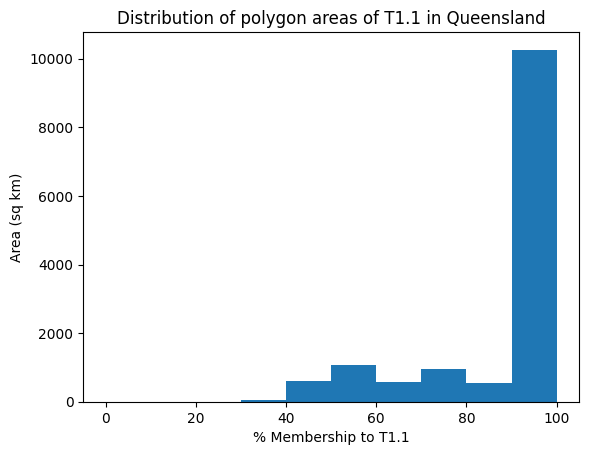

In [33]:
plt.hist(T1_1.pc1, bins=10, range=[0, 100], 
    weights=(T1_1.geometry.area/1e6)) # in square kilometers
plt.xlabel('% Membership to T1.1')
plt.ylabel('Area (sq km)')
plt.title('Distribution of polygon areas of T1.1 in Queensland')
plt.show()

<Axes: >

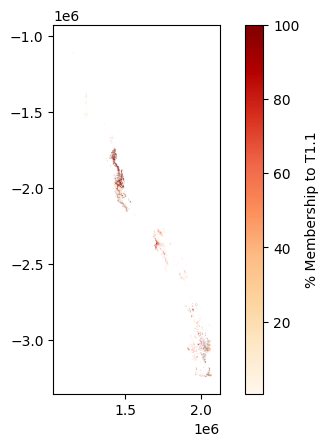

In [17]:
T1_1.plot(column='membership', legend=True, cmap='OrRd', 
             legend_kwds={"label": "% Membership to T1.1", "orientation": "vertical"})

In [52]:
T1_1['certainty'] = pd.cut(T1_1.pc1, bins=[0, 33, 66, 100], labels=['Unlike', 'As likely as not', 'Very likely T1.1'])

In [54]:
T1_1_groups = T1_1[['certainty', 'geometry']]

T1_1_zones = T1_1_groups.dissolve(by='certainty')

In [55]:
T1_1_zones.geometry.area/1e6

certainty
Unlike                 45.930346
As likely as not     2254.627515
Very likely T1.1    11764.752505
dtype: float64

In [57]:
T1_1_zones

,geometry
certainty,
Unlike,"MULTIPOLYGON (((1983991.125 -2961301.983, 1984..."
As likely as not,"MULTIPOLYGON (((1699950.546 -2400781.742, 1699..."
Very likely T1.1,"MULTIPOLYGON (((1407926.849 -1866310.926, 1407..."


In [58]:
T1_1_zones.to_file(repodir / 'gisdata' / 'T1_1_Queensland.gpkg', layer='T1_1_likelihood', driver="GPKG")

In [60]:
T1_1[['re','percent','bvg1m','membership','geometry']].to_file(repodir / 'gisdata' / 'T1_1_Queensland.gpkg', layer='T1_1', driver="GPKG")